# Data Wrangling Project
TDW6323 DATA WRANGLING AND VISUALIZATION

Section 1A - Group 5

Members:
1. 242UT2449Z	KHO WEI CONG
2. 242UT244B2	TEE KIAN HAO
3. 242UT2449P	SEE CHWAN KAI
4. 242UT24490	TEO JING AN


In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
# Load dataset
df = pd.read_csv("Online Sales Data.csv")

# Display first few rows
df.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [ ]:
# Number of rows and columns
df.shape

# Column names and data types
df.info()

# Check unique values for categorical columns
df.select_dtypes(include="object").nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    240 non-null    int64  
 1   Date              240 non-null    object 
 2   Product Category  240 non-null    object 
 3   Product Name      240 non-null    object 
 4   Units Sold        240 non-null    int64  
 5   Unit Price        240 non-null    float64
 6   Total Revenue     240 non-null    float64
 7   Region            240 non-null    object 
 8   Payment Method    240 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 17.0+ KB


Date                240
Product Category      6
Product Name        232
Region                3
Payment Method        3
dtype: int64

In [ ]:
# Show min and max for numerical columns
df[['Transaction ID', 'Units Sold', 'Unit Price', 'Total Revenue']].agg(['min', 'max'])

# Integer columns
df[['Transaction ID', 'Units Sold']].agg(['min', 'max'])

# Float columns
df[['Unit Price', 'Total Revenue']].agg(['min', 'max'])

df.select_dtypes(include=['int64', 'float64']).agg(['min', 'max'])


,Transaction ID,Units Sold,Unit Price,Total Revenue
min,10001,1,6.50,6.50
max,10240,10,3899.99,3899.99


In [ ]:
# Check for missing values
df.isnull().sum()

Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64

In [16]:
# Check duplicates
df.duplicated().sum()

0

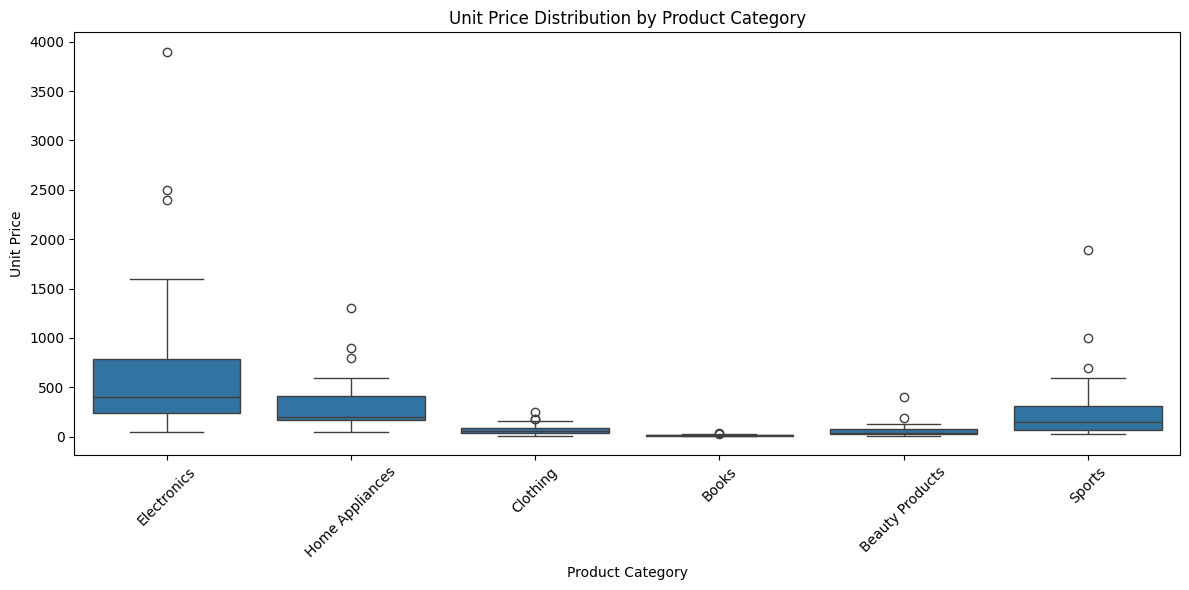

In [ ]:
# Check outliers for Unit Price
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x='Product Category',
    y='Unit Price'
)
plt.title('Unit Price Distribution by Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


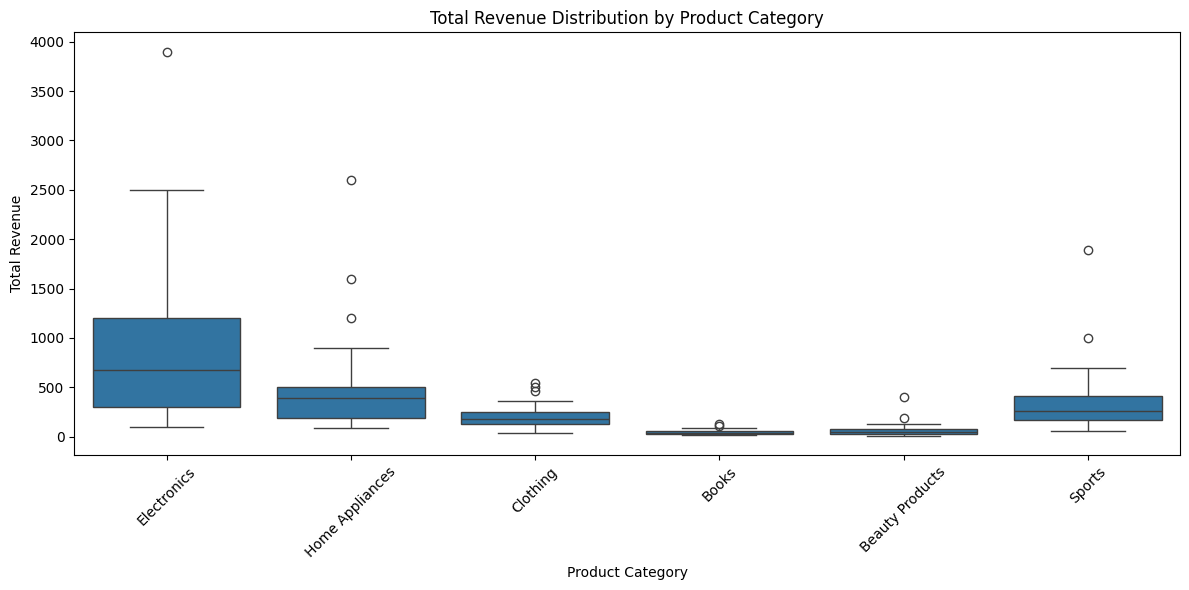

In [ ]:
# Check outliers for total revenue
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x='Product Category',
    y='Total Revenue'
)
plt.title('Total Revenue Distribution by Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Remove outliers using Z-score method
def remove_outliers_zscore(df, group_col, value_col, threshold=3):
    df_clean = []

    for category, group in df.groupby(group_col):
        z_scores = np.abs(zscore(group[value_col]))
        clean_group = group[z_scores <= threshold]
        df_clean.append(clean_group)

    return pd.concat(df_clean)

# Remove outliers for 'Unit Price'
df_no_unitprice_outliers = remove_outliers_zscore(
    df,
    group_col='Product Category',
    value_col='Unit Price',
    threshold=3
)

# Remove outliers for 'Total Revenue'
df = remove_outliers_zscore(
    df_no_unitprice_outliers,
    group_col='Product Category',
    value_col='Total Revenue',
    threshold=3
)

# Display shape after removing outliers
print("After removing outliers:", df.shape)


After removing outliers: (230, 9)


In [ ]:
# Recalculate total price
df["Calculated Total"] = df["Units Sold"] * df["Unit Price"]

# Identify incorrect total price values
incorrect_total = df[df["Total Revenue"] != df["Calculated Total"]]

# Replace incorrect values
df.loc[df["Total Revenue"] != df["Calculated Total"], "Total Revenue"] = df["Calculated Total"]

# Drop helper column
df.drop(columns=["Calculated Total"], inplace=True)

In [ ]:
# Convert 'Date' column to 3 new columns: 'Year', 'Month', 'Day'
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [55]:
# Final data overview
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    240 non-null    int64  
 1   Date              240 non-null    object 
 2   Product Category  240 non-null    object 
 3   Product Name      240 non-null    object 
 4   Units Sold        240 non-null    int64  
 5   Unit Price        240 non-null    float64
 6   Total Revenue     240 non-null    float64
 7   Region            240 non-null    object 
 8   Payment Method    240 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 17.0+ KB


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [ ]:
# Select numeric columns only for statistical analysis
numeric_df = df.select_dtypes(include=["int64", "float64"])

In [ ]:
stats_summary = pd.DataFrame({
    "Sum": numeric_df.sum(),
    "Mean": numeric_df.mean(),
    "Median": numeric_df.median(),
    "Min": numeric_df.min(),
    "Max": numeric_df.max(),
    "Range": numeric_df.max() - numeric_df.min(),
    "Variance": numeric_df.var(),
    "Std Dev": numeric_df.std()
})

# display
stats_summary

,Sum,Mean,Median,Min,Max,Range,Variance,Std Dev
Transaction ID,2328289.00,10122.995652,10124.500,10001.0,10240.00,239.00,4762.091684,69.007910
Units Sold,497.00,2.160870,2.000,1.0,10.00,9.00,1.716366,1.310102
Unit Price,46877.51,203.815261,85.995,6.5,2499.99,2493.49,111512.479028,333.934842
Total Revenue,67813.00,294.839130,162.480,6.5,2499.99,2493.49,146649.844340,382.948880


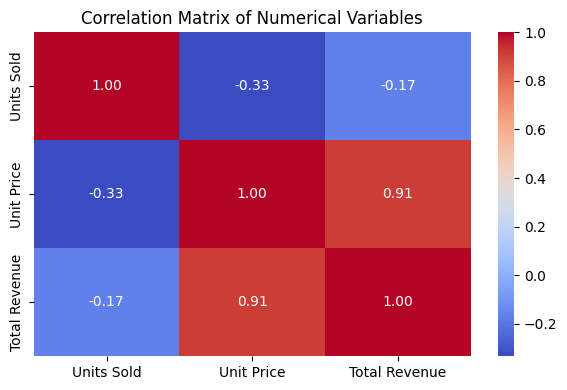

In [ ]:
# Correlation matrix
corr_matrix = df[['Units Sold', 'Unit Price', 'Total Revenue']].corr()
corr_matrix

plt.figure(figsize=(6,4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

In [ ]:
# Visualization: Distribution of Units Sold
fig_units = px.histogram(
    df,
    x='Units Sold',
    nbins=10,
    title='Distribution of Units Sold'
)

fig_units.update_traces(
    hovertemplate='Units Sold: %{x}<br>Count: %{y}<extra></extra>'
)

fig_units.update_layout(
    xaxis_title='Units Sold',
    yaxis_title='Frequency'
)

fig_units.show()

In [ ]:
# Visualization: Distribution of Unit Price
fig_price = px.histogram(
    df,
    x='Unit Price',
    nbins=30,
    title='Distribution of Unit Price'
)

fig_price.update_traces(
    hovertemplate='Unit Price: %{x:.2f}<br>Count: %{y}<extra></extra>'
)

fig_price.update_layout(
    xaxis_title='Unit Price',
    yaxis_title='Frequency'
)

fig_price.show()


In [ ]:
# Visualization: Distribution of Total Revenue
fig_revenue = px.histogram(
    df,
    x='Total Revenue',
    nbins=30,
    title='Distribution of Total Revenue'
)

fig_revenue.update_traces(
    hovertemplate='Total Revenue: %{x:.2f}<br>Count: %{y}<extra></extra>'
)

fig_revenue.update_layout(
    xaxis_title='Total Revenue',
    yaxis_title='Frequency'
)

fig_revenue.show()

In [ ]:
# Question 1: Which product categories generate the highest total revenue?

category_revenue = (
    df.groupby('Product Category')['Total Revenue']
      .sum()
      .reset_index()
)

fig1 = px.bar(
    category_revenue,
    x='Product Category',
    y='Total Revenue',
    text='Total Revenue',
    title='Total Revenue by Product Category'
)

# tooltip formatting
fig1.update_traces(
    hovertemplate='Category: %{x}<br>Total Revenue: %{y:.2f}<extra></extra>'
)

fig1.update_layout(
    xaxis_title='Product Category',
    yaxis_title='Total Revenue',
    xaxis_tickangle=-45
)

fig1.show()


In [ ]:
# Question 2: Are there seasonal patterns in total revenue across different months?

# Aggregate monthly revenue
monthly_revenue = (
    df.groupby(['Year', 'Month'])['Total Revenue']
      .sum()
      .reset_index()
)

# Create a Year-Month column for plotting
monthly_revenue['Year-Month'] = (
    monthly_revenue['Year'].astype(str) + '-' +
    monthly_revenue['Month'].astype(str).str.zfill(2)
)

fig = px.line(
    monthly_revenue,
    x='Year-Month',
    y='Total Revenue',
    markers=True,
    title='Monthly Total Revenue Trend'
)

# tooltip formatting
fig.update_traces(
    hovertemplate='Month: %{x}<br>Total Revenue: %{y:.2f}<extra></extra>'
)

fig.update_layout(
    xaxis_title='Year-Month',
    yaxis_title='Total Revenue',
    xaxis=dict(
        rangeslider=dict(visible=True),  # Range slider
        type='category'
    )
)

fig.show()

In [ ]:
# Question 3: Which regions contribute the most to overall sales revenue?

region_revenue = (
    df.groupby('Region')['Total Revenue']
      .sum()
      .reset_index()
)

fig3 = px.bar(
    region_revenue,
    x='Region',
    y='Total Revenue',
    title='Total Revenue by Region',
    text='Total Revenue'
)

# tooltip formatting
fig3.update_traces(
    hovertemplate='Region: %{x}<br>Total Revenue: %{y:.2f}<extra></extra>'
)

fig3.update_layout(
    xaxis_title='Region',
    yaxis_title='Total Revenue'
)

fig3.show()


In [ ]:
# Question 4: Does the choice of payment method vary across product categories or regions?

# Prepare data
cat_data = df.groupby(['Product Category', 'Payment Method']).size().unstack(fill_value=0)
reg_data = df.groupby(['Region', 'Payment Method']).size().unstack(fill_value=0)

fig = go.Figure()

# Add category traces (initially visible)
for method in cat_data.columns:
    fig.add_trace(go.Bar(
        x=cat_data.index,
        y=cat_data[method],
        name=method,
        visible=True
    ))

# Add region traces (initially hidden)
for method in reg_data.columns:
    fig.add_trace(go.Bar(
        x=reg_data.index,
        y=reg_data[method],
        name=method,
        visible=False
    ))

num_methods = len(cat_data.columns)

fig.update_layout(
    barmode='stack',
    title='Payment Method Distribution by Product Category',
    yaxis_title='Transaction Count',
    updatemenus=[
        dict(
            buttons=[ # buttons for dropdown
                dict(
                    label="By Product Category",
                    method="update",
                    args=[
                        {"visible": [True]*num_methods + [False]*num_methods},
                        {"title": "Payment Method Distribution by Product Category",
                         "xaxis": {"title": "Product Category"}}
                    ]
                ),
                dict(
                    label="By Region",
                    method="update",
                    args=[
                        {"visible": [False]*num_methods + [True]*num_methods},
                        {"title": "Payment Method Distribution by Region",
                         "xaxis": {"title": "Region"}}
                    ]
                )
            ]
        )
    ]
)

fig.show()